# Notebook 04 — GRU Training
Trains the GRU baseline using the same hyperparameter grid as LSTM for fair comparison.

In [15]:
import subprocess, os
from pathlib import Path

REPO_URL  = 'https://github.com/calvinkatoroy/tugas-akhir-ai-kel-08.git'
REPO_NAME = 'tugas-akhir-ai-kel-08'

cwd = Path.cwd()

if (cwd / '../src').resolve().exists():
    result = subprocess.run(['git', '-C', str((cwd / '..').resolve()), 'pull'],
                            capture_output=True, text=True)
    print(result.stdout.strip() or 'Already up to date.')

elif (cwd / 'src').exists():
    result = subprocess.run(['git', 'pull'], capture_output=True, text=True)
    print(result.stdout.strip() or 'Already up to date.')
    os.chdir('notebooks')

else:
    repo_path = cwd / REPO_NAME
    if not repo_path.exists():
        print(f'Cloning {REPO_URL} ...')
        subprocess.run(['git', 'clone', REPO_URL], check=True)
    else:
        print('Repo found, pulling latest...')
        subprocess.run(['git', '-C', str(repo_path), 'pull'], capture_output=True)
    os.chdir(repo_path / 'notebooks')

print(f'Working dir: {Path.cwd()}')

Updating a1ffd6b..a9a5972
Fast-forward
 notebooks/03_lstm_training.ipynb | 56 +++-----------------------------
 notebooks/04_gru_training.ipynb  | 52 +++--------------------------
 notebooks/05_rf_training.ipynb   | 70 ++--------------------------------------
 notebooks/06_evaluation.ipynb    | 28 ++--------------
 4 files changed, 14 insertions(+), 192 deletions(-)
Working dir: /content/tugas-akhir-ai-kel-08/notebooks


In [2]:
import sys
sys.path.insert(0, '..')

import random
import copy
import numpy as np
import torch
import yaml
from pathlib import Path

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [3]:
from google.colab import drive
from pathlib import Path

IN_COLAB = "google.colab" in str(get_ipython())
if IN_COLAB:
    drive.mount("/content/drive")
    DRIVE_ROOT = Path("/content/drive/MyDrive/tugas-akhir-ai")
    SPLITS_DIR = DRIVE_ROOT / "splits"
else:
    import yaml
    with open("../config.yaml") as f:
        _cfg = yaml.safe_load(f)
    SPLITS_DIR = Path("..") / _cfg["data"]["splits_path"]
print(f"SPLITS_DIR: {SPLITS_DIR}")

Mounted at /content/drive
SPLITS_DIR: /content/drive/MyDrive/tugas-akhir-ai/splits


In [4]:
with open("../config.yaml") as f:
    cfg = yaml.safe_load(f)

X_train = np.load(SPLITS_DIR / "X_train_seq.npy")
y_train = np.load(SPLITS_DIR / "y_train_seq.npy")
X_val   = np.load(SPLITS_DIR / "X_val_seq.npy")
y_val   = np.load(SPLITS_DIR / "y_val_seq.npy")
X_test  = np.load(SPLITS_DIR / "X_test_seq.npy")
y_test  = np.load(SPLITS_DIR / "y_test_seq.npy")

n_features = X_train.shape[2]
seq_len    = X_train.shape[1]
print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")
print(f"n_features={n_features}, seq_len={seq_len}")

Train: (301950, 10, 16)  Val: (64696, 10, 16)  Test: (64698, 10, 16)
n_features=16, seq_len=10


## Baseline run (config defaults)

In [5]:
from src.models.gru_model import build_gru
from src.train import train_model
from src.utils import log_experiment

model = build_gru(cfg, n_features)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')

GRUClassifier(
  (gru): GRU(16, 128, num_layers=2, batch_first=True, dropout=0.3)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)
Trainable parameters: 163,522


In [6]:
history_baseline, ckpt_baseline = train_model(
    model, X_train, y_train, X_val, y_val,
    cfg=cfg, model_key='gru',
    checkpoint_dir='../results/checkpoints',
)

log_experiment({
    'exp_id': 'gru_01_baseline',
    'model': 'GRU',
    'hidden_size': cfg['gru']['hidden_size'],
    'num_layers': cfg['gru']['num_layers'],
    'dropout': cfg['gru']['dropout'],
    'seq_len': cfg['gru']['seq_len'],
    'lr': cfg['gru']['learning_rate'],
    'batch_size': cfg['gru']['batch_size'],
    'best_val_f1': round(max(history_baseline['val_f1']), 4),
    'notes': 'baseline — config defaults',
}, csv_path='../results/metrics_summary.csv')

Training GRU:   0%|          | 0/50 [00:00<?, ?it/s]

  Epoch   1/50 | train_loss=0.0587 acc=0.9768 | val_loss=0.0343 acc=0.9900 f1=0.9935 | 18.0s
  Epoch  10/50 | train_loss=0.0164 acc=0.9956 | val_loss=0.0155 acc=0.9956 f1=0.9971 | 18.5s
  Epoch  20/50 | train_loss=0.0092 acc=0.9968 | val_loss=0.0188 acc=0.9956 f1=0.9972 | 17.6s
  Epoch  30/50 | train_loss=0.0049 acc=0.9979 | val_loss=0.0268 acc=0.9959 f1=0.9974 | 17.3s
  Epoch  40/50 | train_loss=0.0037 acc=0.9984 | val_loss=0.0318 acc=0.9960 f1=0.9974 | 17.4s
  Epoch  50/50 | train_loss=0.0033 acc=0.9986 | val_loss=0.0336 acc=0.9960 f1=0.9974 | 17.7s
  Best val F1: 0.9974 — checkpoint: ../results/checkpoints/best_gru.pt


## Hyperparameter Experiments

In [7]:
def run_gru_experiment(exp_id, overrides, notes=''):
    exp_cfg = copy.deepcopy(cfg)
    exp_cfg['gru'].update(overrides)

    random.seed(SEED); np.random.seed(SEED)
    torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

    m = build_gru(exp_cfg, n_features)
    hist, ckpt = train_model(
        m, X_train, y_train, X_val, y_val,
        cfg=exp_cfg, model_key='gru',
        checkpoint_dir='../results/checkpoints',
    )
    best_f1 = round(max(hist['val_f1']), 4)
    log_experiment({
        'exp_id': exp_id,
        'model': 'GRU',
        'hidden_size': exp_cfg['gru']['hidden_size'],
        'num_layers': exp_cfg['gru']['num_layers'],
        'dropout': exp_cfg['gru']['dropout'],
        'seq_len': exp_cfg['gru']['seq_len'],
        'lr': exp_cfg['gru']['learning_rate'],
        'batch_size': exp_cfg['gru']['batch_size'],
        'best_val_f1': best_f1,
        'notes': notes,
    }, csv_path='../results/metrics_summary.csv')
    print(f'[{exp_id}] best_val_f1={best_f1}')
    return hist, ckpt, best_f1

In [8]:
hist_02, _, f1_02 = run_gru_experiment('gru_02_hidden64',  {'hidden_size': 64},  'hidden_size=64')

Training GRU:   0%|          | 0/50 [00:00<?, ?it/s]

  Epoch   1/50 | train_loss=0.0660 acc=0.9760 | val_loss=0.0369 acc=0.9869 f1=0.9915 | 17.5s
  Epoch  10/50 | train_loss=0.0178 acc=0.9954 | val_loss=0.0162 acc=0.9957 f1=0.9972 | 17.2s
  Epoch  20/50 | train_loss=0.0116 acc=0.9962 | val_loss=0.0174 acc=0.9959 f1=0.9973 | 18.3s
  Epoch  30/50 | train_loss=0.0089 acc=0.9968 | val_loss=0.0182 acc=0.9956 f1=0.9972 | 17.2s
  Epoch  40/50 | train_loss=0.0074 acc=0.9973 | val_loss=0.0198 acc=0.9959 f1=0.9973 | 17.0s
  Epoch  50/50 | train_loss=0.0071 acc=0.9974 | val_loss=0.0209 acc=0.9959 f1=0.9973 | 17.2s
  Best val F1: 0.9973 — checkpoint: ../results/checkpoints/best_gru.pt
[gru_02_hidden64] best_val_f1=0.9973


In [9]:
hist_03, _, f1_03 = run_gru_experiment('gru_03_hidden256', {'hidden_size': 256}, 'hidden_size=256')

Training GRU:   0%|          | 0/50 [00:00<?, ?it/s]

  Epoch   1/50 | train_loss=0.0586 acc=0.9774 | val_loss=0.0355 acc=0.9884 f1=0.9925 | 22.9s
  Epoch  10/50 | train_loss=0.0184 acc=0.9955 | val_loss=0.0184 acc=0.9957 f1=0.9972 | 21.9s
  Epoch  20/50 | train_loss=0.0139 acc=0.9961 | val_loss=0.0148 acc=0.9962 f1=0.9975 | 21.9s
  Epoch  30/50 | train_loss=0.0095 acc=0.9970 | val_loss=0.0173 acc=0.9962 f1=0.9976 | 21.9s
  Epoch  40/50 | train_loss=0.0052 acc=0.9980 | val_loss=0.0232 acc=0.9962 f1=0.9975 | 20.8s
  Epoch  50/50 | train_loss=0.0039 acc=0.9985 | val_loss=0.0298 acc=0.9962 f1=0.9976 | 22.4s
  Best val F1: 0.9976 — checkpoint: ../results/checkpoints/best_gru.pt
[gru_03_hidden256] best_val_f1=0.9976


In [10]:
hist_04, _, f1_04 = run_gru_experiment('gru_04_layers3',   {'num_layers': 3},    'num_layers=3')

Training GRU:   0%|          | 0/50 [00:00<?, ?it/s]

  Epoch   1/50 | train_loss=0.0652 acc=0.9753 | val_loss=0.0378 acc=0.9883 f1=0.9924 | 19.6s
  Epoch  10/50 | train_loss=0.0192 acc=0.9952 | val_loss=0.0161 acc=0.9956 f1=0.9971 | 19.1s
  Epoch  20/50 | train_loss=0.0144 acc=0.9960 | val_loss=0.0151 acc=0.9958 f1=0.9973 | 20.2s
  Epoch  30/50 | train_loss=0.0115 acc=0.9965 | val_loss=0.0158 acc=0.9958 f1=0.9973 | 19.5s
  Epoch  40/50 | train_loss=0.0103 acc=0.9967 | val_loss=0.0166 acc=0.9957 f1=0.9972 | 19.3s
  Epoch  50/50 | train_loss=0.0097 acc=0.9969 | val_loss=0.0174 acc=0.9958 f1=0.9973 | 19.3s
  Best val F1: 0.9974 — checkpoint: ../results/checkpoints/best_gru.pt
[gru_04_layers3] best_val_f1=0.9974


In [11]:
hist_05, _, f1_05 = run_gru_experiment('gru_05_lr1e4',     {'learning_rate': 1e-4}, 'lr=1e-4')

Training GRU:   0%|          | 0/50 [00:00<?, ?it/s]

  Epoch   1/50 | train_loss=0.1099 acc=0.9532 | val_loss=0.0694 acc=0.9677 f1=0.9789 | 18.0s
  Epoch  10/50 | train_loss=0.0299 acc=0.9920 | val_loss=0.0280 acc=0.9922 f1=0.9949 | 18.2s
  Epoch  20/50 | train_loss=0.0230 acc=0.9945 | val_loss=0.0229 acc=0.9935 f1=0.9958 | 17.8s
  Epoch  30/50 | train_loss=0.0201 acc=0.9952 | val_loss=0.0206 acc=0.9950 f1=0.9968 | 18.4s
  Epoch  40/50 | train_loss=0.0190 acc=0.9953 | val_loss=0.0202 acc=0.9949 f1=0.9967 | 17.7s
  Epoch  50/50 | train_loss=0.0186 acc=0.9955 | val_loss=0.0202 acc=0.9950 f1=0.9967 | 18.4s
  Best val F1: 0.9969 — checkpoint: ../results/checkpoints/best_gru.pt
[gru_05_lr1e4] best_val_f1=0.9969


In [12]:
# Exp 06 — dropout=0.5
hist_06, _, f1_06 = run_gru_experiment('gru_06_dropout05', {'dropout': 0.5}, 'dropout=0.5')

Training GRU:   0%|          | 0/50 [00:00<?, ?it/s]

  Epoch   1/50 | train_loss=0.0660 acc=0.9691 | val_loss=0.0444 acc=0.9888 f1=0.9928 | 17.6s
  Epoch  10/50 | train_loss=0.0210 acc=0.9949 | val_loss=0.0183 acc=0.9954 f1=0.9970 | 18.6s
  Epoch  20/50 | train_loss=0.0144 acc=0.9958 | val_loss=0.0150 acc=0.9958 f1=0.9973 | 18.1s
  Epoch  30/50 | train_loss=0.0111 acc=0.9963 | val_loss=0.0166 acc=0.9958 f1=0.9973 | 18.3s
  Epoch  40/50 | train_loss=0.0100 acc=0.9965 | val_loss=0.0165 acc=0.9959 f1=0.9973 | 18.3s
  Epoch  50/50 | train_loss=0.0097 acc=0.9966 | val_loss=0.0171 acc=0.9959 f1=0.9973 | 17.4s
  Best val F1: 0.9974 — checkpoint: ../results/checkpoints/best_gru.pt
[gru_06_dropout05] best_val_f1=0.9974


In [25]:
import os
csv_path = '../results/metrics_summary.csv'
if os.path.exists(csv_path): os.remove(csv_path)

experiments = [
    ('gru_01_baseline', history_baseline, cfg['gru'], 'baseline — config defaults'),
    ('gru_02_hidden64',  hist_02, {**cfg['gru'], 'hidden_size': 64},     'hidden_size=64'),
    ('gru_03_hidden256', hist_03, {**cfg['gru'], 'hidden_size': 256},    'hidden_size=256'),
    ('gru_04_layers3',   hist_04, {**cfg['gru'], 'num_layers': 3},       'num_layers=3'),
    ('gru_05_lr1e4',     hist_05, {**cfg['gru'], 'learning_rate': 1e-4}, 'lr=1e-4'),
    ('gru_06_dropout05', hist_06, {**cfg['gru'], 'dropout': 0.5},        'dropout=0.5'),
]
for exp_id, hist, ecfg, notes in experiments:
    log_experiment({
        'exp_id': exp_id, 'model': 'GRU',
        'hidden_size': ecfg['hidden_size'], 'num_layers': ecfg['num_layers'],
        'dropout': ecfg['dropout'], 'seq_len': ecfg['seq_len'],
        'lr': ecfg['learning_rate'], 'batch_size': ecfg['batch_size'],
        'best_val_f1': round(max(hist['val_f1']), 4), 'notes': notes,
    }, csv_path=csv_path)
print('Done')


Done


In [26]:
import pandas as pd
df = pd.read_csv(CSV_PATH)
print(df.columns.tolist())
print(df.head())


['exp_id', 'model', 'hidden_size', 'num_layers', 'dropout', 'seq_len', 'lr', 'batch_size', 'best_val_f1', 'notes']
              exp_id model  hidden_size  num_layers  dropout  seq_len     lr  \
0   lstm_01_baseline  LSTM          128           2      0.3       10  0.001   
1   lstm_02_hidden64  LSTM           64           2      0.3       10  0.001   
2  lstm_03_hidden256  LSTM          256           2      0.3       10  0.001   
3    lstm_04_layers3  LSTM          128           3      0.3       10  0.001   
4  lstm_05_dropout05  LSTM          128           2      0.5       10  0.001   

   batch_size  best_val_f1                       notes  
0          64       0.9974  baseline — config defaults  
1          64       0.9973              hidden_size=64  
2          64       0.9976             hidden_size=256  
3          64       0.9974                num_layers=3  
4          64       0.9969                 dropout=0.5  


## Final Evaluation on Test Set

In [27]:
import pandas as pd

results = pd.read_csv(CSV_PATH)  # bukan '../results/metrics_summary.csv'
lstm_results = results[results['model'] == 'LSTM'].copy()
print(lstm_results[['exp_id', 'hidden_size', 'num_layers', 'dropout',
                     'seq_len', 'lr', 'best_val_f1', 'notes']])

best_row = lstm_results.loc[lstm_results['best_val_f1'].idxmax()]
print(f'\nBest experiment: {best_row["exp_id"]}  val_F1={best_row["best_val_f1"]}')

_hist_map = {
    "lstm_01_baseline": history_baseline,
    "lstm_02_hidden64": hist_02,
    "lstm_03_hidden256": hist_03,
    "lstm_04_layers3": hist_04,
    "lstm_05_dropout05": hist_05,
    "lstm_06_seqlen5": hist_06,
}
best_history = _hist_map.get(best_row["exp_id"], history_baseline)


              exp_id  hidden_size  num_layers  dropout  seq_len     lr  \
0   lstm_01_baseline          128           2      0.3       10  0.001   
1   lstm_02_hidden64           64           2      0.3       10  0.001   
2  lstm_03_hidden256          256           2      0.3       10  0.001   
3    lstm_04_layers3          128           3      0.3       10  0.001   
4  lstm_05_dropout05          128           2      0.5       10  0.001   
5    lstm_06_seqlen5          128           2      0.3        5  0.001   

   best_val_f1                       notes  
0       0.9974  baseline — config defaults  
1       0.9973              hidden_size=64  
2       0.9976             hidden_size=256  
3       0.9974                num_layers=3  
4       0.9969                 dropout=0.5  
5       0.9974                   seq_len=5  

Best experiment: lstm_03_hidden256  val_F1=0.9976



=== GRU — Classification Report ===
              precision    recall  f1-score   support

      normal       0.99      1.00      0.99     14672
        ddos       1.00      1.00      1.00     50026

    accuracy                           1.00     64698
   macro avg       0.99      1.00      0.99     64698
weighted avg       1.00      1.00      1.00     64698



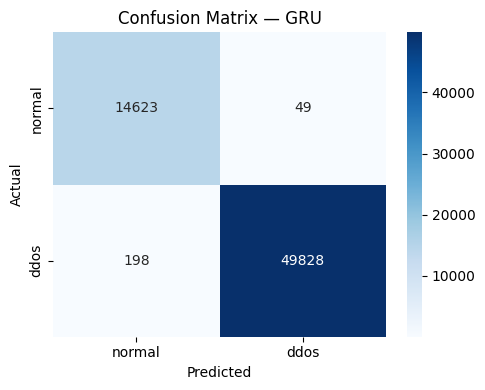

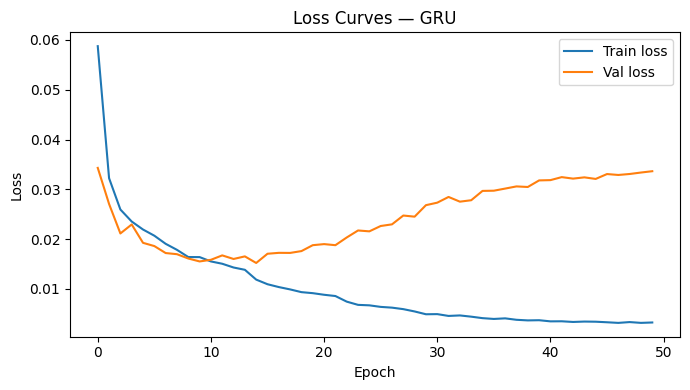

  FPR=0.0033  ROC-AUC=0.9995


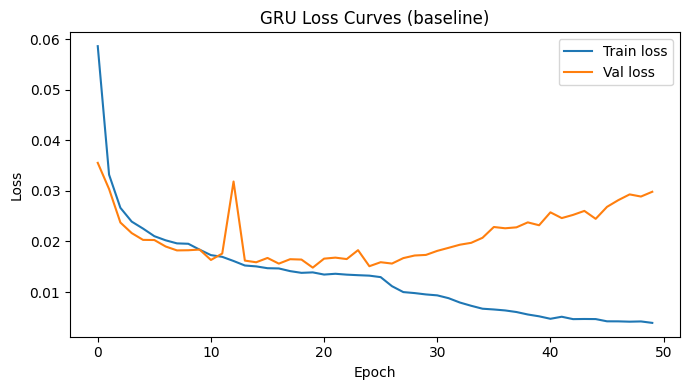

In [28]:
from src.models.gru_model import build_gru
from src.evaluate import evaluate_dl_model
from src.utils import plot_loss_curves

best_model = build_gru(cfg, n_features).to(device)
best_model.load_state_dict(torch.load('../results/checkpoints/best_gru.pt', map_location=device))

y_pred_gru, y_prob_gru = evaluate_dl_model(
    best_model, X_test, y_test,
    model_name='GRU',
    history=history_baseline,
    figures_dir='../results/figures',
    csv_path='../results/metrics_summary.csv',
)

np.save('../results/gru_y_prob.npy', y_prob_gru)

plot_loss_curves(
    best_history['train_loss'], best_history['val_loss'],
    title='GRU Loss Curves (baseline)',
    save_path='../results/figures/loss_gru.png',
)